In [27]:
import numpy as np
import pandas as pd
import geopandas as gpd
gs_results = pd.read_csv("/home/felipe/Desktop/Trabajo/WFL_scripts/results/gridsearch_result.csv")



In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_heatmap_ax(
    fig, ax, df, config_val, num_col, fmt=".2f", cmap="viridis"
):
    """Plots an annotated heatmap of 'fn' vs 'polygon' for a selected 'config' category

    onto a provided Matplotlib Figure and Axes object.

    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        The parent figure object (needed for adding the colorbar).
    ax : matplotlib.axes.Axes
        The specific subplot axes where the heatmap will be drawn.
    df : pandas.DataFrame
        Input DataFrame.
    config_val : str or int
        The category value in the 'config' column to filter by.
    num_col : str
        The numerical column to plot ('fitness', 'aep_wake', 'park_cf',
        'park_loss').
    fmt : str, default '.2f'
        Format specifier for cell values (e.g., '.2f', '.1f', '.0f').
    cmap : str, default 'viridis'
        Matplotlib colormap scheme.
    """
    # 1. Filter DataFrame by the given config
    filtered_df = df

    if filtered_df.empty:
        raise ValueError(f"No rows found for config = '{config_val}'")

    # 2. Pivot the data (Swapped index and columns)
    pivot_df = filtered_df.pivot(index="fn", columns="polygon", values=num_col)

    data_matrix = pivot_df.values
    row_labels = pivot_df.index.tolist()
    col_labels = pivot_df.columns.tolist()

    # 3. Draw heatmap on the passed `ax`
    im = ax.imshow(data_matrix, cmap=cmap, aspect="auto")

    # Add colorbar attached to the parent `fig`
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(num_col, rotation=-90, va="bottom", fontsize=10)

    # Set tick labels
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)

    # Axis labels and title (Swapped x and y labels)
    ax.set_xlabel("Polygon", fontsize=11)
    ax.set_ylabel("FN", fontsize=11)
    ax.set_title(f"{num_col}", fontsize=12, pad=10)

    # 4. Annotate cells with adaptive text color for readability
    norm = im.norm
    cmap_obj = plt.get_cmap(cmap)

    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            val = data_matrix[i, j]
            if not np.isnan(val):
                # Calculate relative luminance to decide white/black text
                rgba = cmap_obj(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "white" if luminance < 0.5 else "black"

                ax.text(
                    j,
                    i,
                    f"{val:{fmt}}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontweight="bold",
                )

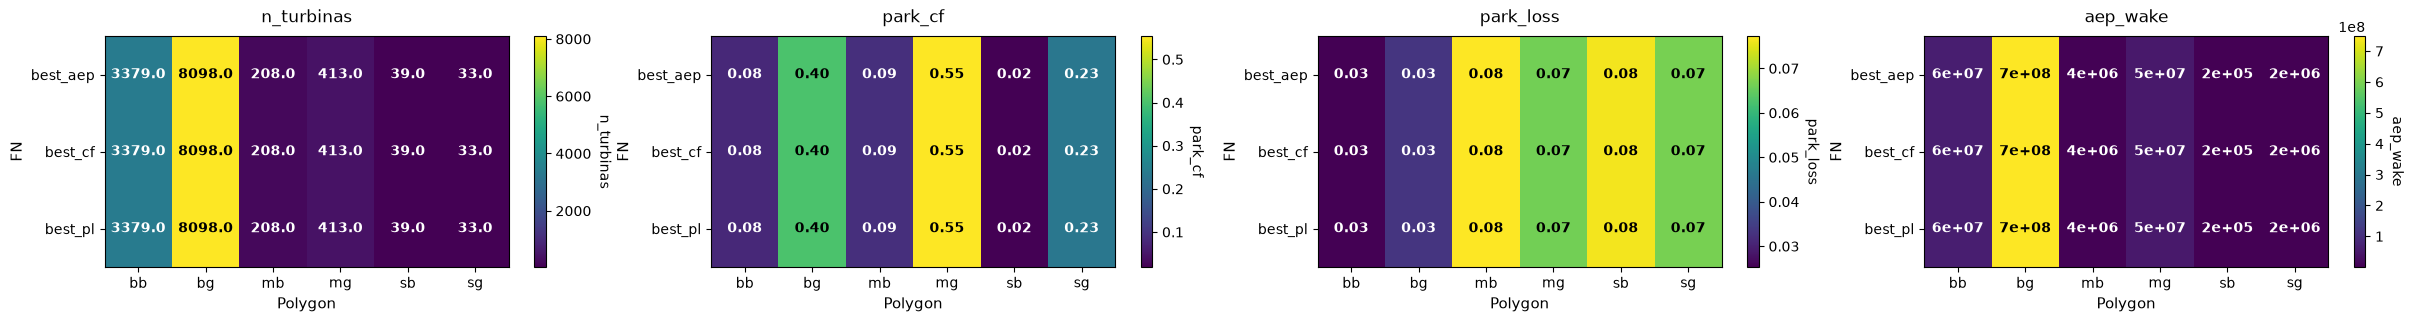

In [29]:
import math
def plot_all_results(df):
    configs = df["config"].unique()

    fig, axes = plt.subplots(1, 4, figsize=(30, 3))
    plot_heatmap_ax(fig, axes[0], df, "c", "n_turbinas", fmt=".1f")
    plot_heatmap_ax(fig, axes[1], df, "c", "park_cf")
    plot_heatmap_ax(fig, axes[2], df, "c", "park_loss")
    plot_heatmap_ax(fig, axes[3], df, "c", "aep_wake", fmt=".0e")


plot_all_results(gs_results)
